# Xây dựng và đánh giá các thuật toán phân loại hình ảnh rác

Notebook này triển khai pipeline xử lý ảnh cho bài toán phân loại rác tái chế. Các bước chính gồm: tải dữ liệu TrashNet, khám phá dữ liệu, minh họa từng bước xử lý ảnh, trích xuất đặc trưng HOG và huấn luyện mô hình SVM baseline.

## 1. Import thư viện và cấu hình chung

In [37]:
from pathlib import Path
import zipfile
import shutil
import time

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from huggingface_hub import hf_hub_download

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.cluster import KMeans

from skimage.feature import hog
from skimage import exposure

RANDOM_STATE = 42
IMG_SIZE = (128, 128)

DATA_BASE = Path("data")
RAW_DIR = DATA_BASE / "raw"
DATA_DIR = DATA_BASE / "trashnet_resized"

RAW_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (8, 5)
sns.set_theme(style="whitegrid")

## 2. Tải dataset TrashNet bản resized

Dataset TrashNet có 6 lớp: cardboard, glass, metal, paper, plastic và trash. Notebook dùng file `dataset-resized.zip` vì nhẹ hơn bản ảnh gốc và phù hợp để chạy trên máy cá nhân.

In [38]:
zip_path = hf_hub_download(
    repo_id="garythung/trashnet",
    filename="dataset-resized.zip",
    repo_type="dataset",
    local_dir=str(RAW_DIR)
)

print("Đường dẫn file zip:", zip_path)

Đường dẫn file zip: D:\Dongphh\CVision\lab\data\raw\dataset-resized.zip


## 3. Giải nén và xác định thư mục dữ liệu

In [39]:
ZIP_PATH = Path(zip_path)
extract_dir = DATA_BASE / "dataset-resized"

if not DATA_DIR.exists():
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(DATA_BASE)

    if extract_dir.exists():
        shutil.move(str(extract_dir), str(DATA_DIR))

classes = sorted([p.name for p in DATA_DIR.iterdir() if p.is_dir()])

print("DATA_DIR:", DATA_DIR)
print("Các lớp:", classes)

DATA_DIR: data\trashnet_resized
Các lớp: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


## 4. Tạo bảng quản lý đường dẫn ảnh và nhãn

In [40]:
valid_exts = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

image_paths = []
labels = []

for class_dir in DATA_DIR.iterdir():
    if class_dir.is_dir():
        for img_path in class_dir.rglob("*"):
            if img_path.suffix.lower() in valid_exts:
                image_paths.append(img_path)
                labels.append(class_dir.name)

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

classes = sorted(df["label"].unique())

print(df.head())
print("Tổng số ảnh:", len(df))
print("Các lớp:", classes)
print(df["label"].value_counts())

                                         image_path      label
0    data\trashnet_resized\cardboard\cardboard1.jpg  cardboard
1   data\trashnet_resized\cardboard\cardboard10.jpg  cardboard
2  data\trashnet_resized\cardboard\cardboard100.jpg  cardboard
3  data\trashnet_resized\cardboard\cardboard101.jpg  cardboard
4  data\trashnet_resized\cardboard\cardboard102.jpg  cardboard
Tổng số ảnh: 2527
Các lớp: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
label
paper        594
glass        501
plastic      482
metal        410
cardboard    403
trash        137
Name: count, dtype: int64


## 5. Khám phá phân bố số lượng ảnh theo lớp

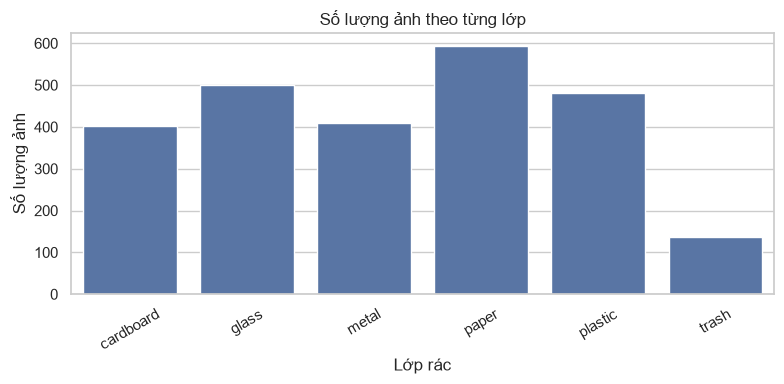

In [41]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="label", order=classes)
plt.title("Số lượng ảnh theo từng lớp")
plt.xlabel("Lớp rác")
plt.ylabel("Số lượng ảnh")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 6. Hiển thị ảnh mẫu của từng lớp

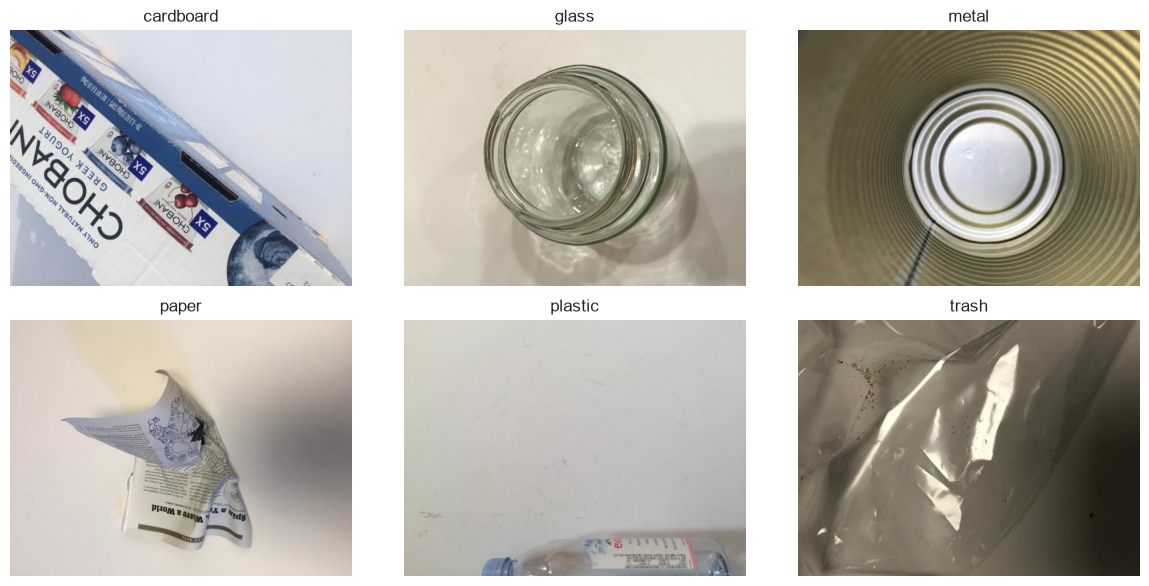

In [42]:
plt.figure(figsize=(12, 6))

for i, class_name in enumerate(classes):
    sample = df[df["label"] == class_name].sample(1, random_state=RANDOM_STATE).iloc[0]

    img_bgr = cv2.imread(str(sample["image_path"]))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img_rgb)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

## 7. Chọn một ảnh mẫu để minh họa pipeline xử lý ảnh

Ảnh mẫu: data\trashnet_resized\paper\paper494.jpg
Nhãn: paper
Kích thước ảnh gốc: (384, 512, 3)


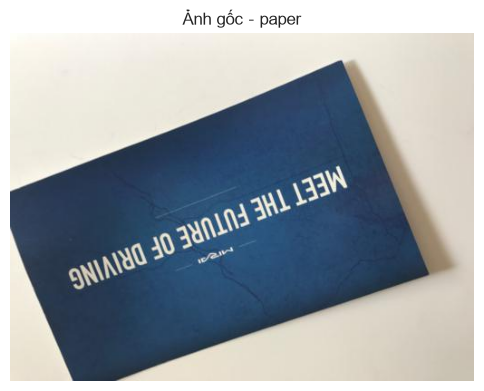

In [43]:
sample_row = df.sample(1, random_state=RANDOM_STATE).iloc[0]
sample_path = sample_row["image_path"]
sample_label = sample_row["label"]

img_bgr = cv2.imread(str(sample_path))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print("Ảnh mẫu:", sample_path)
print("Nhãn:", sample_label)
print("Kích thước ảnh gốc:", img_rgb.shape)

plt.figure(figsize=(5, 4))
plt.imshow(img_rgb)
plt.title(f"Ảnh gốc - {sample_label}")
plt.axis("off")
plt.tight_layout()
plt.show()

## 8. Bước tiền xử lý: resize và chuyển grayscale

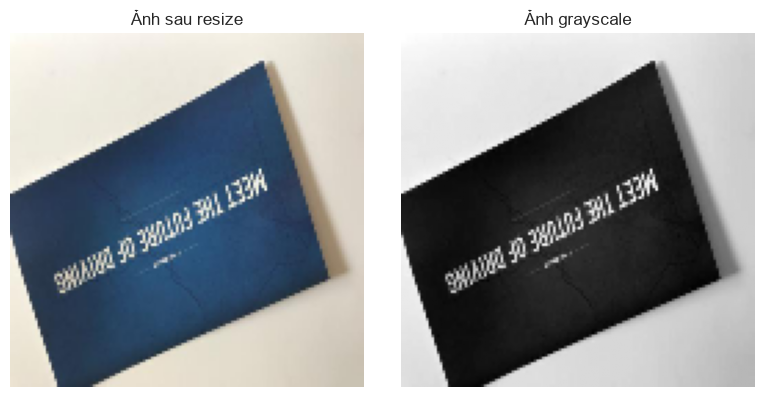

Kích thước sau resize: (128, 128, 3)


In [44]:
img_resized = cv2.resize(img_rgb, IMG_SIZE)
img_gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_resized)
plt.title("Ảnh sau resize")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_gray, cmap="gray")
plt.title("Ảnh grayscale")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Kích thước sau resize:", img_resized.shape)

## 9. Bước phân cụm màu bằng K-means

K-means được dùng để phân cụm màu ảnh, giúp tách vùng vật thể và nền. Đây là phần ứng dụng kiến thức phân cụm trong xử lý ảnh.

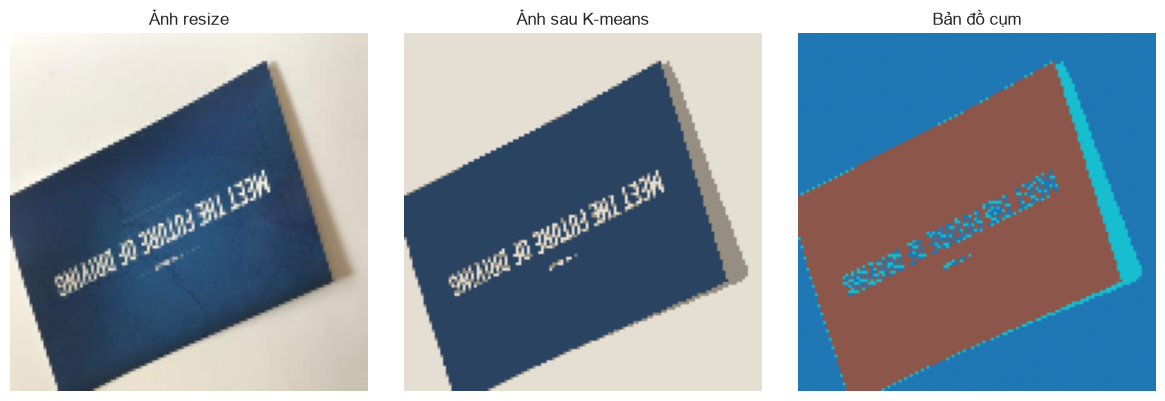

In [45]:
def kmeans_segment_image(img_rgb, k=3, img_size=IMG_SIZE):
    img_small = cv2.resize(img_rgb, img_size)
    pixels = img_small.reshape(-1, 3)

    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    cluster_ids = kmeans.fit_predict(pixels)
    centers = kmeans.cluster_centers_.astype(np.uint8)

    segmented_pixels = centers[cluster_ids]
    segmented_img = segmented_pixels.reshape(img_small.shape)
    label_map = cluster_ids.reshape(img_small.shape[:2])

    return img_small, segmented_img, label_map

img_small, segmented_img, label_map = kmeans_segment_image(img_rgb, k=3)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_small)
plt.title("Ảnh resize")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(segmented_img)
plt.title("Ảnh sau K-means")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(label_map, cmap="tab10")
plt.title("Bản đồ cụm")
plt.axis("off")

plt.tight_layout()
plt.show()

## 10. Tạo mask, morphology và contour

Sau khi có bản đồ cụm, ta tạo mask foreground, làm sạch bằng phép toán hình thái học, sau đó tìm contour lớn nhất để lấy vùng vật thể.

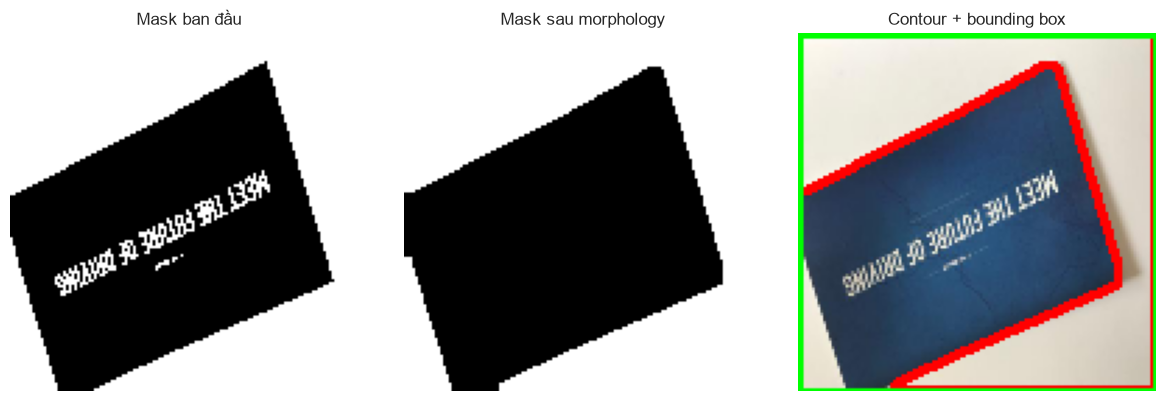

Bounding box: (0, 0, 128, 128)


In [46]:
def create_foreground_mask(label_map, kernel_size=5):
    unique_labels, counts = np.unique(label_map, return_counts=True)
    background_label = unique_labels[np.argmax(counts)]

    mask = np.where(label_map != background_label, 255, 0).astype(np.uint8)

    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    mask_clean = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_CLOSE, kernel)

    return mask, mask_clean


def draw_largest_contour(img_rgb, mask_clean):
    contours, _ = cv2.findContours(
        mask_clean,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    contour_img = img_rgb.copy()
    bbox = None

    if len(contours) > 0:
        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)
        bbox = (x, y, w, h)

        cv2.drawContours(contour_img, [largest_contour], -1, (255, 0, 0), 2)
        cv2.rectangle(contour_img, (x, y), (x + w, y + h), (0, 255, 0), 2)

    return contour_img, bbox

mask, mask_clean = create_foreground_mask(label_map, kernel_size=5)
contour_img, bbox = draw_largest_contour(img_small, mask_clean)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(mask, cmap="gray")
plt.title("Mask ban đầu")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_clean, cmap="gray")
plt.title("Mask sau morphology")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(contour_img)
plt.title("Contour + bounding box")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Bounding box:", bbox)

## 11. Trích xuất đặc trưng HOG và hiển thị HOG visualization

HOG mô tả hướng gradient của ảnh, phù hợp để biểu diễn hình dạng và biên của vật thể.

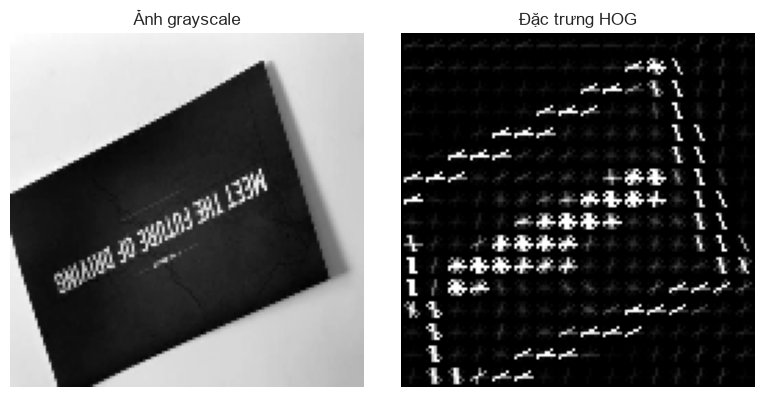

Số chiều vector HOG: (8100,)


In [47]:
hog_features, hog_image = hog(
    img_gray,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
    visualize=True,
    feature_vector=True
)

hog_image_rescaled = exposure.rescale_intensity(
    hog_image,
    in_range=(0, 10)
)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap="gray")
plt.title("Ảnh grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hog_image_rescaled, cmap="gray")
plt.title("Đặc trưng HOG")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Số chiều vector HOG:", hog_features.shape)

## 12. Chia dữ liệu train/test

In [48]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df["label"]
)

print("Train:", len(train_df))
print("Test:", len(test_df))
print("Phân bố train:")
print(train_df["label"].value_counts())
print("Phân bố test:")
print(test_df["label"].value_counts())

Train: 2021
Test: 506
Phân bố train:
label
paper        475
glass        401
plastic      385
metal        328
cardboard    322
trash        110
Name: count, dtype: int64
Phân bố test:
label
paper        119
glass        100
plastic       97
metal         82
cardboard     81
trash         27
Name: count, dtype: int64


## 13. Xây dựng hàm đọc ảnh và trích xuất HOG cho toàn bộ dataset

In [49]:
def load_image_rgb(image_path, img_size=IMG_SIZE):
    img_bgr = cv2.imread(str(image_path))

    if img_bgr is None:
        raise ValueError(f"Không đọc được ảnh: {image_path}")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, img_size)

    return img_rgb


def extract_hog_features(img_rgb):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        visualize=False,
        feature_vector=True
    )

    return features


def build_hog_dataset(dataframe):
    X = []
    y = []

    for _, row in dataframe.iterrows():
        img = load_image_rgb(row["image_path"])
        features = extract_hog_features(img)

        X.append(features)
        y.append(row["label"])

    return np.array(X), np.array(y)

## 14. Tạo ma trận đặc trưng cho train/test

In [50]:
start_time = time.time()

X_train, y_train = build_hog_dataset(train_df)
X_test, y_test = build_hog_dataset(test_df)

elapsed = time.time() - start_time

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print(f"Thời gian trích xuất đặc trưng: {elapsed:.2f} giây")

X_train: (2021, 8100)
X_test: (506, 8100)
Thời gian trích xuất đặc trưng: 16.30 giây


## 15. Huấn luyện Baseline 1: HOG + SVM

In [51]:
baseline_hog_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=1.0, random_state=RANDOM_STATE))
])

start_time = time.time()
baseline_hog_svm.fit(X_train, y_train)
train_time = time.time() - start_time

print(f"Thời gian huấn luyện: {train_time:.2f} giây")

Thời gian huấn luyện: 23.44 giây


## 16. Đánh giá mô hình bằng accuracy và classification report

In [52]:
start_time = time.time()
y_pred = baseline_hog_svm.predict(X_test)
predict_time = time.time() - start_time

acc = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"Thời gian dự đoán toàn bộ test set: {predict_time:.2f} giây")
print(f"Thời gian dự đoán trung bình mỗi ảnh: {predict_time / len(y_test):.6f} giây")
print("Classification report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.5870
Thời gian dự đoán toàn bộ test set: 3.66 giây
Thời gian dự đoán trung bình mỗi ảnh: 0.007236 giây
Classification report:
              precision    recall  f1-score   support

   cardboard       0.68      0.77      0.72        81
       glass       0.45      0.52      0.48       100
       metal       0.54      0.52      0.53        82
       paper       0.75      0.71      0.73       119
     plastic       0.45      0.41      0.43        97
       trash       0.88      0.56      0.68        27

    accuracy                           0.59       506
   macro avg       0.62      0.58      0.60       506
weighted avg       0.59      0.59      0.59       506



## 17. Confusion matrix

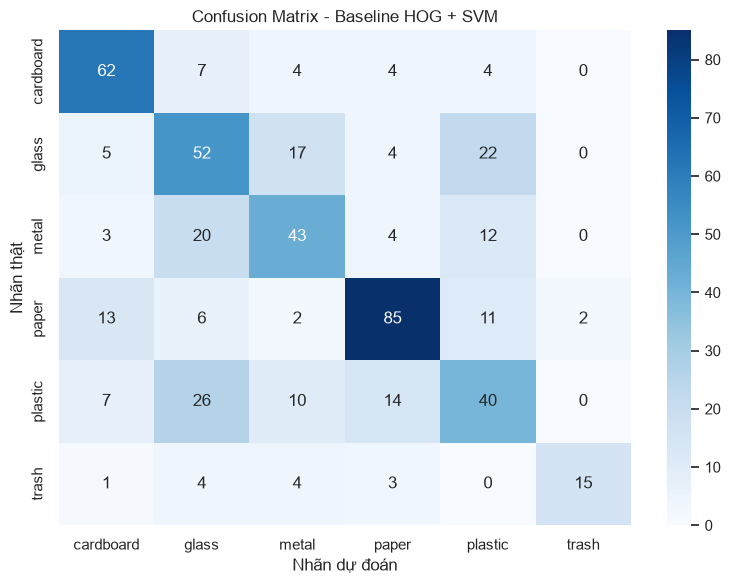

In [53]:
cm = confusion_matrix(y_test, y_pred, labels=classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Nhãn dự đoán")
plt.ylabel("Nhãn thật")
plt.title("Confusion Matrix - Baseline HOG + SVM")
plt.tight_layout()
plt.show()

## 18. Thử dự đoán một ảnh bất kỳ trong tập test

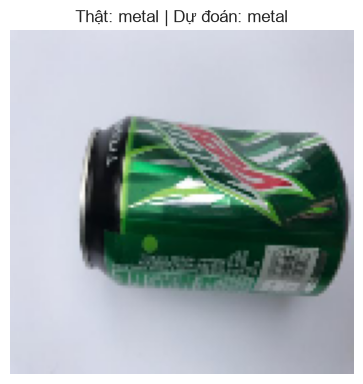

In [54]:
sample_test = test_df.sample(1, random_state=RANDOM_STATE).iloc[0]
img = load_image_rgb(sample_test["image_path"])
features = extract_hog_features(img).reshape(1, -1)
pred_label = baseline_hog_svm.predict(features)[0]
true_label = sample_test["label"]

plt.figure(figsize=(5, 4))
plt.imshow(img)
plt.title(f"Thật: {true_label} | Dự đoán: {pred_label}")
plt.axis("off")
plt.tight_layout()
plt.show()

## 19. Ghi chú kết quả thí nghiệm

Sau khi chạy xong notebook, cần ghi lại các thông tin sau để đưa vào báo cáo:

- Accuracy của Baseline 1.
- Macro precision, macro recall, macro F1-score.
- Các lớp dễ bị nhầm trong confusion matrix.
- Thời gian trích xuất đặc trưng, thời gian huấn luyện và thời gian dự đoán.
- Nhận xét: HOG + SVM là baseline truyền thống, chưa dùng segmentation nên có thể bị ảnh hưởng bởi nền ảnh và ánh sáng.